In [7]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np

sys.path.insert(0, str(Path.cwd().parent))  # points to src/
from shared_modeling import (
    compute_hassles_uplifts,
    compute_resilience_score,
    compute_stress_average,
    compute_stress_level,
    load_or_create_master_split_ids,
    run_model_experiment,
)
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_curve, auc, f1_score
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline  # Use imblearn's Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.inspection import permutation_importance
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
import numpy as np
import shap
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK


In [8]:
def create_pipeline(preprocessor, classifier, use_smote=True, poly_features=False, pca_components=None):
    steps = [('preprocessor', preprocessor)]
    
    if pca_components:
        steps.append(('pca', PCA(n_components=pca_components)))
    
    if poly_features:
        steps.append(('poly', PolynomialFeatures(degree=2, include_bias=False)))
        
    if use_smote:
        steps.append(('smote', SMOTE(random_state=42)))
        
    steps.append(('classifier', classifier))
    
    return ImbPipeline(steps=steps)

# Example usage:
# pipeline = create_pipeline(preprocessor, LogisticRegression(solver='liblinear', penalty='l2', C=0.1, max_iter=1000), poly_features=True)


In [17]:
def get_feature_names_from_pipeline(model, X_train=None):
    """Return feature names after preprocessing when a pipeline is used."""
    if hasattr(model, 'named_steps') and 'preprocessor' in model.named_steps:
        try:
            return np.asarray(model.named_steps['preprocessor'].get_feature_names_out())
        except Exception:
            pass
    if X_train is not None:
        return np.asarray(X_train.columns)
    return None


def plot_confusion_matrix_for_model(model, X_test, y_test, labels=None, title='Confusion Matrix'):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_roc_curve_for_model(model, X_test, y_test, title='ROC Curve'):
    if not hasattr(model, 'predict_proba'):
        print('ROC curve skipped: model does not expose predict_proba().')
        return
    y_score = model.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_score)
    plt.title(f"{title} (AUC={roc_auc_score(y_test, y_score):.3f})")
    plt.tight_layout()
    plt.show()


def plot_model_feature_importance(model, X_train=None, top_n=20, title='Feature Importance'):
    feature_names = get_feature_names_from_pipeline(model, X_train)
    classifier = model.named_steps['classifier'] if hasattr(model, 'named_steps') and 'classifier' in model.named_steps else model

    if hasattr(classifier, 'feature_importances_'):
        importances = classifier.feature_importances_
    elif hasattr(classifier, 'coef_'):
        importances = np.abs(np.ravel(classifier.coef_))
    else:
        print('Feature importance skipped: model does not expose coefficients or feature_importances_.')
        return None

    if feature_names is None:
        feature_names = np.array([f'feature_{i}' for i in range(len(importances))])
    else:
        feature_names = np.asarray(feature_names)[: len(importances)]
        importances = importances[: len(feature_names)]

    fi = pd.DataFrame({'feature': feature_names, 'importance': importances})
    fi = fi.sort_values('importance', ascending=False).head(top_n)
    plt.figure(figsize=(10, max(4, 0.35 * len(fi))))
    plt.barh(fi['feature'][::-1], fi['importance'][::-1])
    plt.title(title)
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
    return fi


def plot_permutation_importance_for_model(model, X_test, y_test, top_n=20, title='Permutation Importance'):
    feature_names = np.asarray(X_test.columns) if hasattr(X_test, 'columns') else np.array([f'feature_{i}' for i in range(X_test.shape[1])]) if hasattr(X_test, 'shape') else get_feature_names_from_pipeline(model, X_test)
    result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

    if feature_names is None:
        feature_names = np.array([f'feature_{i}' for i in range(len(result.importances_mean))])
    else:
        feature_names = np.asarray(feature_names)[: len(result.importances_mean)]

    pi = pd.DataFrame({
        'feature': feature_names,
        'importance_mean': result.importances_mean,
        'importance_std': result.importances_std,
    }).sort_values('importance_mean', ascending=False).head(top_n)

    plt.figure(figsize=(10, max(4, 0.35 * len(pi))))
    plt.barh(pi['feature'][::-1], pi['importance_mean'][::-1], xerr=pi['importance_std'][::-1])
    plt.title(title)
    plt.xlabel('Permutation Importance')
    plt.tight_layout()
    plt.show()
    return pi


def plot_shap_summary_for_model(model, X_train, X_test, max_display=20, sample_size=500):
    """Generate SHAP summary plots for tree-based or linear models when supported."""
    classifier = model.named_steps['classifier'] if hasattr(model, 'named_steps') and 'classifier' in model.named_steps else model
    feature_names = get_feature_names_from_pipeline(model, X_train)

    X_shap = X_test.sample(min(sample_size, len(X_test)), random_state=42) if len(X_test) > sample_size else X_test

    try:
        if hasattr(model, 'named_steps') and 'preprocessor' in model.named_steps:
            X_shap_transformed = model.named_steps['preprocessor'].transform(X_shap)
        else:
            X_shap_transformed = X_shap

        explainer = shap.Explainer(classifier, X_shap_transformed)
        shap_values = explainer(X_shap_transformed)
        shap.summary_plot(shap_values, X_shap_transformed, feature_names=feature_names, max_display=max_display, show=True)
        return shap_values
    except Exception as exc:
        print(f'SHAP skipped: {exc}')
        return None


def run_interpretability_suite(model, X_train, X_test, y_test, labels=None, top_n=20):
    """Run the standard combined-model interpretability outputs."""
    plot_confusion_matrix_for_model(model, X_test, y_test, labels=labels)
    plot_roc_curve_for_model(model, X_test, y_test)
    plot_model_feature_importance(model, X_train=X_train, top_n=top_n)
    plot_permutation_importance_for_model(model, X_test, y_test, top_n=top_n)
    plot_shap_summary_for_model(model, X_train, X_test, max_display=top_n)


In [12]:
# Maternal physical health features
maternal_physical_features = ['oDM', 'acog_PEgHTN', 'ChronHTN']  # pregnancy-related physical health predictors
df_maternal_physical = pd.read_csv('../../Data/PREGNANCY_OUTCOMES.csv', usecols=maternal_physical_features + ['PublicID'])

# Maternal mental health features
# Resilience (V2I)
v2i_cols = ['PublicID'] + [f'V2IA{i:02d}' for i in range(1, 26)]
df_v2i = pd.read_csv('../../Data/V2I.csv', usecols=v2i_cols)
# Stress average (V1E)
v1e_cols = ['PublicID', 'V1EA01', 'V1EA02a', 'V1EA02b', 'V1EA02c', 'V1EA02d', 'V1EA02e', 'V1EA02f', 'V1EA02g', 'V1EA02h', 'V1EA02i', 'V1EA02j', 'V1EA02k', 'V1EA02l']
df_v1e = pd.read_csv('../../Data/V1E.CSV', usecols=v1e_cols, encoding='ISO-8859-1')
# Hassle/uplift intensity and frequency ratios (V3J)
v3j_cols = ['PublicID'] + [f'V3JA01{letter}' for letter in 'abcdefghij'] + [f'V3JA02{letter}' for letter in 'abcdefghij']
df_v3j = pd.read_csv('../../Data/V3J.csv', usecols=v3j_cols)
# Stress level binning (V1A + V3A)
v1a_stress_cols = ['PublicID', 'V1AH04', 'V1AH05', 'V1AH07', 'V1AH08']
v3a_stress_cols = ['PublicID', 'V3AG04', 'V3AG05', 'V3AG07', 'V3AG08']
df_v1a_stress = pd.read_csv('../../Data/V1A.CSV', usecols=v1a_stress_cols)
df_v3a_stress = pd.read_csv('../../Data/V3A.CSV', usecols=v3a_stress_cols)

# Paternal demographics (Demo_father)
paternal_features = ['V2AF13', 'V2AF15']  # father's age and years of education
df_paternal = pd.read_csv('../../Data/V2A.csv', usecols=paternal_features + ['PublicID'], low_memory=False)
df_paternal[paternal_features] = df_paternal[paternal_features].replace({'R': np.nan, 'D': np.nan})
df_paternal[paternal_features] = df_paternal[paternal_features].apply(pd.to_numeric, errors='coerce')

# Drug use (Drugs)
drug_features = ['V2AH01', 'V2AH02', 'V2AH03', 'V2AH04', 'V2AH05', 'V2AH06']
df_drugs = pd.read_csv('../../Data/V2A.csv', usecols=drug_features + ['PublicID'], low_memory=False)
df_drugs = df_drugs.replace({'R': np.nan, 'D': np.nan})
df_drugs[drug_features] = df_drugs[drug_features].apply(pd.to_numeric, errors='coerce')

# Food / nutrition (Food_Model)
food_features = ['DT_FOLAC', 'DT_CALC', 'VITD_MCG', 'TOTAL_CHOLINE', 'DT_SODI', 'PRENATALYEARS', 'PRENATALAMOUNT', 'AHEI2010', 'AHEI_ALCDRKS', 'AHEI_SODIUM', 'AHEI_PUFAPCT', 'AHEI_DHAEPA', 'AHEI_TRFATPCT', 'AHEI_RMEATS', 'AHEI_NUTLEGS', 'AHEI_SUGBEVS', 'AHEI_WGRAINS', 'AHEI_FRUITS', 'AHEI_VEGS', 'DT_ALCO', 'DT_CAFFN', 'DT_FIBE', 'DT_SUG_T', 'DT_CHOL', 'DT_PFAT', 'DT_MFAT', 'DT_SFAT', 'DT_TFAT', 'DT_CARB', 'DT_KCAL', 'DT_PROT', 'DT_VITC', 'DT_VB12', 'DT_VITB6', 'DT_NIAC', 'DT_RIBO', 'DT_THIA', 'DT_IRON', 'DT_TOTN3']
df_food = pd.read_csv('../../Data/FOOD_FREQUENCY_ANALYSIS.csv', usecols=food_features + ['PublicID'])
df_food[food_features] = df_food[food_features].apply(pd.to_numeric, errors='coerce')

# Health knowledge (Health_knowledge_model)
health_knowledge_features = ['V1AD02a', 'V1AD02b', 'V1AD02c', 'V1AD02d', 'V1AD02e', 'V1AD02f', 'V1AD02g', 'V1AD02h', 'V1AD02i', 'V1AD02j', 'V1AD02k']
df_health_knowledge = pd.read_csv('../../Data/V1A.csv', usecols=health_knowledge_features + ['PublicID'])
df_health_knowledge[health_knowledge_features] = df_health_knowledge[health_knowledge_features].apply(pd.to_numeric, errors='coerce')

# Mother demographics (Mother_demo)
mother_numeric_features = ['Age_at_V1', 'V1AF02', 'V1AF10']  # age, years of education, English
mother_categorical_features = ['CRace', 'V1AF14']
df_mother_num = pd.read_csv('../../Data/V1A.CSV', usecols=['V1AF02', 'V1AF14', 'V1AF10', 'PublicID'], encoding='latin-1')
df_mother_demo = pd.read_csv('../../Data/DEMOGRAPHICS.CSV', usecols=['Age_at_V1', 'PublicID', 'CRace'], encoding='latin-1')
df_mother_demo = pd.merge(df_mother_demo, df_mother_num, on='PublicID', how='inner')
df_mother_demo[mother_numeric_features] = df_mother_demo[mother_numeric_features].apply(pd.to_numeric, errors='coerce')
# Derive healthcare access from the response items used in Mother_demo.
healthcare_response_columns = ['V1AF15a', 'V1AF15b', 'V1AF15c', 'V1AF15d', 'V1AF15e', 'V1AF15f', 'V1AF15g']
healthcare_columns = healthcare_response_columns + ['PublicID']
df_healthcare = pd.read_csv('../../Data/V1A.CSV', usecols=healthcare_columns)
df_healthcare['has_healthcare'] = 0
for index, row in df_healthcare.iterrows():
    for column in healthcare_response_columns:
        if row[column] == 1:
            df_healthcare.at[index, 'has_healthcare'] = 1
            break
        elif row[column] == 0:
            df_healthcare.at[index, 'has_healthcare'] = 0
            break
df_mother_demo = pd.merge(df_mother_demo, df_healthcare[['PublicID', 'has_healthcare']], on='PublicID', how='inner')
df_mother_demo = df_mother_demo[~df_mother_demo['V1AF14'].isin(['D', 'R'])]

# Physical activity (Physical Activity)
physical_activity_features = ['V2AJ01a2', 'V2AJ01a1']  # minutes exercised, number of times
df_physical_activity = pd.read_csv('../../Data/V2A.csv', usecols=physical_activity_features + ['PublicID'], low_memory=False)
df_physical_activity[physical_activity_features] = df_physical_activity[physical_activity_features].apply(pd.to_numeric, errors='coerce')

# Sleep (Sleep_model)
sleep_features = ['rest_dur_avg_all_Mod', 'rest_sleeptime_avg_all_Mod', 'sleep_dur_avg_all_Mod', 'sleep_sleeptime_avg_all_Mod', 'sleep_Frag_avg_all_Mod', 'sleep_WASO_avg_all_Mod', 'sleep_SE_avg_all_Mod', 'rest_sleeptime_avg_wkday_Mod']
df_sleep = pd.read_csv('../../Data/modified/SLEEP_ACTIGRAPHY_MODIFIED.CSV', usecols=sleep_features + ['PublicID'])
df_sleep[sleep_features] = df_sleep[sleep_features].apply(pd.to_numeric, errors='coerce')

split_path = 'master_split_ids.csv'
train_ids, test_ids = load_or_create_master_split_ids(df_outcomes, split_path)

# Combine all domain feature tables into one modeling frame.
mental_health_features = compute_resilience_score(df_v2i)
mental_health_features = mental_health_features.merge(compute_stress_average(df_v1e), on='PublicID', how='outer')
mental_health_features = mental_health_features.merge(compute_hassles_uplifts(df_v3j), on='PublicID', how='outer')
mental_health_features = mental_health_features.merge(compute_stress_level(pd.merge(df_v1a_stress, df_v3a_stress, on='PublicID', how='inner')), on='PublicID', how='outer')

combined_df = pd.merge(df_maternal_physical, mental_health_features, on='PublicID', how='left')
combined_df = combined_df.merge(df_paternal, on='PublicID', how='left')
combined_df = combined_df.merge(df_drugs, on='PublicID', how='left')
combined_df = combined_df.merge(df_food, on='PublicID', how='left')
combined_df = combined_df.merge(df_health_knowledge, on='PublicID', how='left')
combined_df = combined_df.merge(df_mother_demo, on='PublicID', how='left')
combined_df = combined_df.merge(df_physical_activity, on='PublicID', how='left')
combined_df = combined_df.merge(df_sleep, on='PublicID', how='left')
combined_df = combined_df.merge(df_outcomes, on='PublicID', how='inner')

numeric_features = [
    # Maternal physical health
    *maternal_physical_features,
    # Maternal mental health
    'ResilienceTotalScore', 'ResilienceLevel', 'stress_average',
    'FrequencyOfHassles', 'FrequencyOfUplifts', 'IntensityOfHassles',
    'IntensityOfUplifts', 'HassleUpliftFrequencyRatio',
    'HassleUpliftIntensityRatio', 'StressTotalScore', 'StressLevel',
    # Paternal demographics
    *paternal_features,
    # Drug use
    *drug_features,
    # Food / nutrition
    *food_features,
    # Health knowledge
    *health_knowledge_features,
    # Mother demographics numeric fields
    *mother_numeric_features,
    'has_healthcare',
    # Physical activity
    *physical_activity_features,
    # Sleep
    *sleep_features,
]
categorical_features = mother_categorical_features
feature_columns = numeric_features + categorical_features

X = combined_df[feature_columns]
y = combined_df['MH_outcome']
train_df = combined_df[combined_df['PublicID'].isin(train_ids)].copy()
test_df = combined_df[combined_df['PublicID'].isin(test_ids)].copy()
X_train = train_df.drop(['MH_outcome', 'PublicID'], axis=1)
X_test = test_df.drop(['MH_outcome', 'PublicID'], axis=1)
y_train = train_df['MH_outcome']
y_test = test_df['MH_outcome']
combined_df


,PublicID,oDM,ChronHTN,acog_PEgHTN,ResilienceTotalScore,ResilienceLevel,stress_average,FrequencyOfHassles,FrequencyOfUplifts,IntensityOfHassles,...,V2AJ01a2,rest_dur_avg_all_Mod,rest_sleeptime_avg_all_Mod,rest_sleeptime_avg_wkday_Mod,sleep_dur_avg_all_Mod,sleep_sleeptime_avg_all_Mod,sleep_Frag_avg_all_Mod,sleep_WASO_avg_all_Mod,sleep_SE_avg_all_Mod,MH_outcome
0,00004O,3.0,2.0,7.0,102.0,1.0,1.846154,10.0,10.0,2.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,00007I,3.0,2.0,7.0,106.0,1.0,1.538462,10.0,10.0,2.0,...,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,00008G,3.0,2.0,7.0,107.0,1.0,2.076923,10.0,10.0,2.2,...,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,00015J,3.0,2.0,7.0,120.0,1.0,1.692308,10.0,10.0,1.4,...,45.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,00016H,3.0,2.0,7.0,97.0,2.0,2.000000,10.0,10.0,1.5,...,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7736,17349I,3.0,2.0,7.0,98.0,2.0,1.461538,10.0,10.0,1.7,...,60.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
7737,17350A,3.0,2.0,3.0,119.0,1.0,1.384615,NaN,NaN,NaN,...,120.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
7738,17351V,3.0,2.0,7.0,104.0,1.0,1.384615,NaN,NaN,NaN,...,NaN,655.000000,574.333313,536.125000,645.833313,569.583313,24.150002,76.25000,86.904999,0
7739,17352T,3.0,2.0,7.0,100.0,2.0,1.538462,10.0,10.0,1.4,...,30.0,436.928558,387.714294,367.799988,428.857147,386.285706,18.521427,42.57143,88.264290,1


In [ ]:
# LR block using all domain features, with mother demographics split into numeric and categorical inputs.
lr_model, lr_pred, lr_metrics = run_model_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    'lr',
    numeric_features,
    categorical_features,
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for 

Best parameters found: {'classifier__C': 0.1, 'classifier__l1_ratio': 0.75}
Best Macro F1 Score: 0.7266
Model Coefficients:
num__oDM: 0.03141620405157937
num__acog_PEgHTN: 0.012448565854612374
num__ChronHTN: -0.07953685366039015
num__ResilienceTotalScore: -0.2649504797621147
num__ResilienceLevel: 0.10953311619877103
num__stress_average: 0.5275523715833923
num__FrequencyOfHassles: 0.0
num__FrequencyOfUplifts: 0.07792173550678386
num__IntensityOfHassles: 0.0
num__IntensityOfUplifts: 0.1770000285746734
num__HassleUpliftFrequencyRatio: 0.0
num__HassleUpliftIntensityRatio: 0.24908319801571277
num__StressTotalScore: 0.7399018411574456
num__StressLevel: -0.029323335382594157
num__V2AF13: -0.007273425767871113
num__V2AF15: 0.0009470052418668549
num__V2AH01: -0.023295464304656097
num__V2AH02: -0.06693242050566046
num__V2AH03: 0.012715019506135334
num__V2AH04: -0.07489154541948573
num__V2AH05: -0.043449212139622245
num__V2AH06: -0.02780929040213313
num__DT_FOLAC: -0.03378276784810703
num__DT_CAL

In [13]:
# RF block using all domain features, with mother demographics split into numeric and categorical inputs.
rf_model, rf_pred, rf_metrics = run_model_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    'rf',
    numeric_features,
    categorical_features,
)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best parameters found: {'classifier__max_depth': 20, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 3, 'classifier__n_estimators': 600}
Best Macro F1 Score: 0.7234
Feature Importances:
num__oDM: 0.0005784304224381079
num__acog_PEgHTN: 0.004394471132337177
num__ChronHTN: 0.0005436070465701038
num__ResilienceTotalScore: 0.05182182723115449
num__ResilienceLevel: 0.03988217212298605
num__stress_average: 0.06938310630568759
num__FrequencyOfHassles: 0.0
num__FrequencyOfUplifts: 0.0
num__IntensityOfHassles: 0.039466284277579
num__IntensityOfUplifts: 0.017039971076961966
num__HassleUpliftFrequencyRatio: 0.0
num__HassleUpliftIntensityRatio: 0.036919494674609234
num__StressTotalScore: 0.10560017812928656
num__StressLevel: 0.048871366854274796
num__V2AF13: 0.013547911301509608
num__V2AF15: 0.014323805324701393
num__V2AH01: 0.0005264243228106345
num__V2AH02: 0.0023460151201090723
num__V2AH03: 1.4845310682662706e-05


In [14]:
# XGBoost block using all domain features, with mother demographics split into numeric and categorical inputs.
xgb_model, xgb_pred, xgb_metrics = run_model_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    'xgb',
    numeric_features,
    categorical_features,
)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best parameters found: {'classifier__colsample_bytree': 0.9, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 6, 'classifier__n_estimators': 100, 'classifier__subsample': 0.7}
Best Macro F1 Score: 0.7300
Feature Importances:
num__oDM: 0.00642867386341095
num__acog_PEgHTN: 0.008068826049566269
num__ChronHTN: 0.010138577781617641
num__ResilienceTotalScore: 0.01237617339938879
num__ResilienceLevel: 0.038305412977933884
num__stress_average: 0.028400296345353127
num__FrequencyOfHassles: 0.0
num__FrequencyOfUplifts: 0.0
num__IntensityOfHassles: 0.011381147429347038
num__IntensityOfUplifts: 0.007276805583387613
num__HassleUpliftFrequencyRatio: 0.0
num__HassleUpliftIntensityRatio: 0.010386287234723568
num__StressTotalScore: 0.06813899427652359
num__StressLevel: 0.05637620761990547
num__V2AF13: 0.006249366793781519
num__V2AF15: 0.009297184646129608
num__V2AH01: 0.005539454519748688
num__V2AH02: 0.011052001267671585
num__

In [15]:
# SVM block using all domain features, with mother demographics split into numeric and categorical inputs.
svm_model, svm_pred, svm_metrics = run_model_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    'svm',
    numeric_features,
    categorical_features,
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters found: {'classifier__estimator__C': 0.1, 'classifier__estimator__kernel': 'linear'}
Best Macro F1 Score: 0.7216
Skipping feature-level SVM output to keep notebook output compact.
Evaluation Metrics for SVM with shared preprocessing and macro F1 grid search:
Accuracy: 0.7230
Precision: 0.7134
Recall: 0.7149
F1-score: 0.7141
ROC AUC: 0.7870


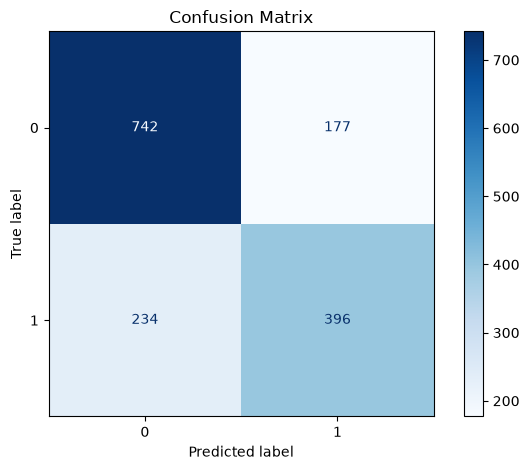

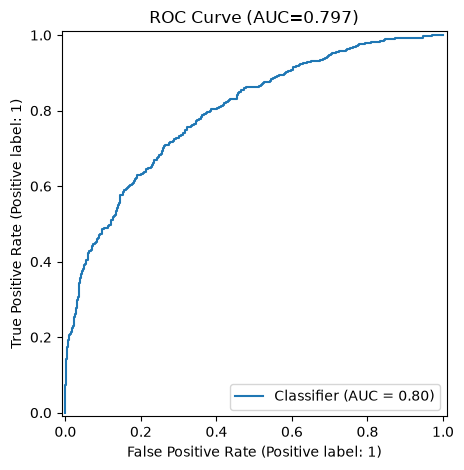

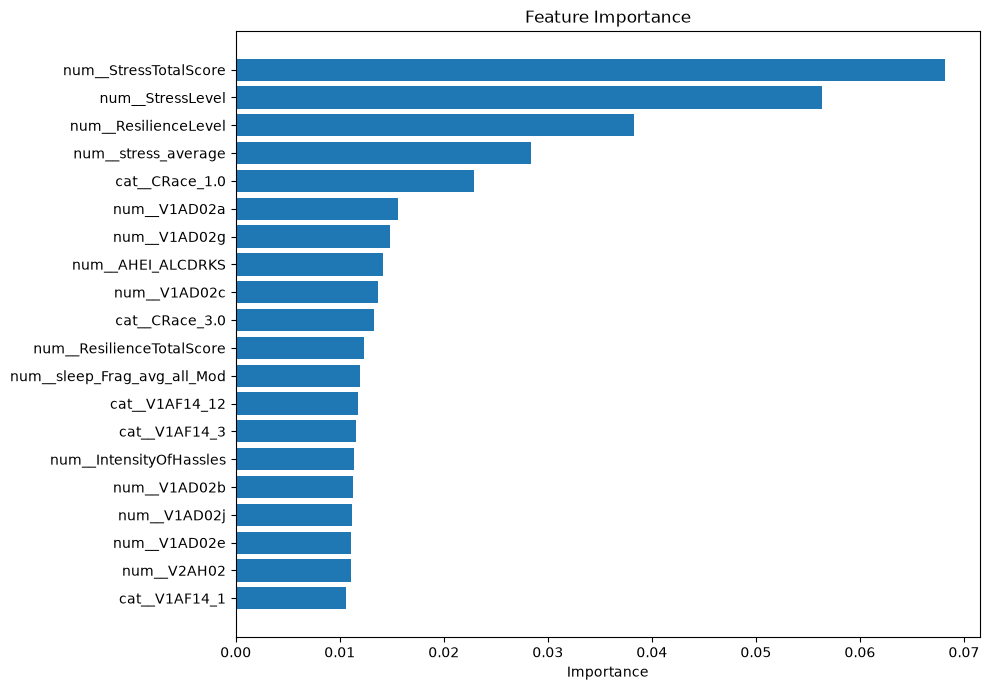

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for 

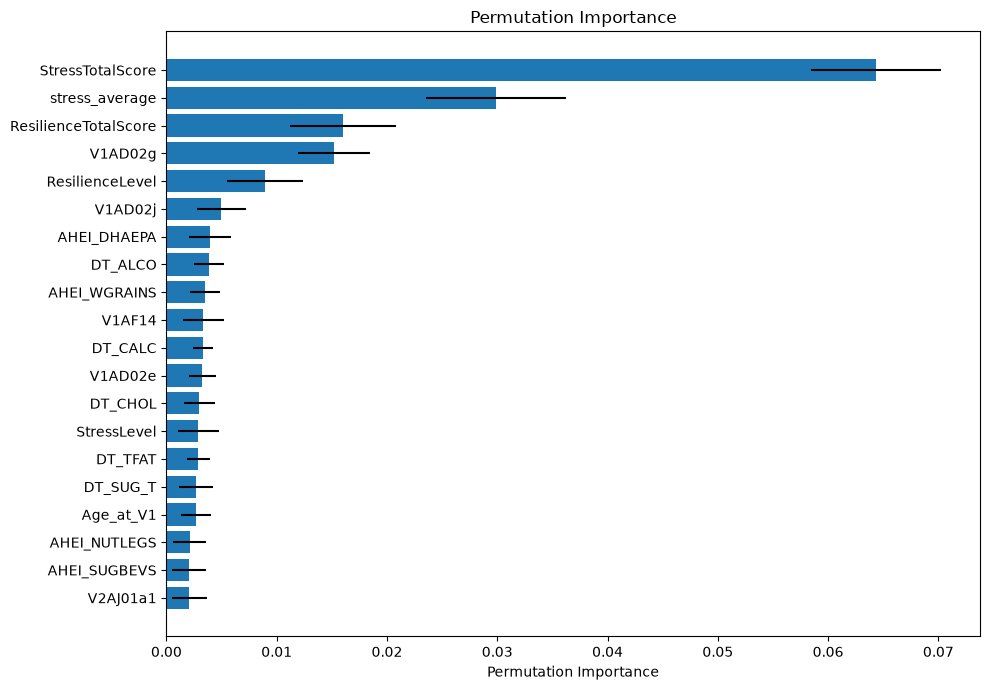

Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


SHAP skipped: Categorical split is not yet supported. You can still use TreeExplainer with `feature_perturbation=tree_path_dependent`.


In [18]:
# Interpretability for the XGB combined model.
# Swap xgb_model for lr_model, rf_model, or svm_model if you want a different view.
run_interpretability_suite(xgb_model, X_train, X_test, y_test, labels=[0, 1], top_n=20)